In [1]:
# Cell 1 — Setup
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils import resample
import warnings
warnings.filterwarnings("ignore")

DB_PATH = "../data/commodity_credit.db"
conn = sqlite3.connect(DB_PATH)

def query(sql):
    return pd.read_sql(sql, conn)

print("Connected!")

Connected!


In [4]:
# Cell 2+3 — Full setup with correct split
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import resample
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

DB_PATH = "../data/commodity_credit.db"
conn = sqlite3.connect(DB_PATH)

def query(sql):
    return pd.read_sql(sql, conn)

# Load data
df = query("""
    SELECT
        o.produto, o.sigla_uf, o.id_fonte_recurso, o.id_programa,
        o.id_tipo_agricultura, o.id_tipo_cultivo, o.ano_emissao,
        o.valor_parcela_credito, o.taxa_juro,
        o.valor_receita_bruta_esperada, o.valor_previsao_producao,
        CAST(JULIANDAY(o.data_vencimento) - JULIANDAY(o.data_emissao) AS INTEGER) AS prazo_dias,
        MAX(CASE WHEN s.id_situacao_operacao IN (2,4,5,6,8,9,12,13) THEN 1 ELSE 0 END) AS inadimplente
    FROM operacoes o
    LEFT JOIN saldo s ON o.id_referencia_bacen = s.id_referencia_bacen
        AND o.numero_ordem = s.numero_ordem
    WHERE o.valor_parcela_credito > 0 AND o.taxa_juro > 0
    GROUP BY o.produto, o.sigla_uf, o.id_fonte_recurso, o.id_programa,
        o.id_tipo_agricultura, o.id_tipo_cultivo, o.ano_emissao,
        o.valor_parcela_credito, o.taxa_juro, o.valor_receita_bruta_esperada,
        o.valor_previsao_producao, o.data_vencimento, o.data_emissao
""")

# Fill missing
for col in ["valor_receita_bruta_esperada", "valor_previsao_producao"]:
    df[col] = df.groupby("produto")[col].transform(lambda x: x.fillna(x.median()))

# Encode categoricals
for col, name in [("produto","produto"), ("sigla_uf","uf"), 
                   ("id_fonte_recurso","fonte"), ("id_programa","programa"),
                   ("id_tipo_agricultura","agri"), ("id_tipo_cultivo","cultivo")]:
    le = LabelEncoder()
    df[f"{name}_enc"] = le.fit_transform(df[col].astype(str))

feature_cols = ["produto_enc", "uf_enc", "fonte_enc", "programa_enc",
                "agri_enc", "cultivo_enc", "ano_emissao",
                "valor_parcela_credito", "taxa_juro",
                "valor_receita_bruta_esperada", "valor_previsao_producao", "prazo_dias"]

X = df[feature_cols]
y = df["inadimplente"]

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Oversample only training set
train_bal = pd.concat([X_train, y_train], axis=1)
majority = train_bal[train_bal["inadimplente"] == 0]
minority = train_bal[train_bal["inadimplente"] == 1]
minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=42)
balanced = pd.concat([majority, minority_up])

X_train_bal = balanced[feature_cols]
y_train_bal = balanced["inadimplente"]

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")
print(f"Train class balance: {y_train_bal.value_counts().to_dict()}")
print(f"Test default rate: {y_test.mean()*100:.2f}%")

Training set: (749934, 12)
Test set: (95166, 12)
Train class balance: {0: 374967, 1: 374967}
Test default rate: 1.50%


In [6]:
# Cell 4 — Train models
models = {
    "Logistic Regression": LogisticRegression(
        penalty="l2", C=1.0, random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train_bal)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "auc": auc
    }
    print(f"  AUC-ROC: {auc:.4f}")
    print(f"  {classification_report(y_test, y_pred)}\n")

print("Training complete!")

Training Logistic Regression...
  AUC-ROC: 0.7859
                precision    recall  f1-score   support

           0       0.99      0.73      0.84     93743
           1       0.04      0.69      0.07      1423

    accuracy                           0.73     95166
   macro avg       0.52      0.71      0.46     95166
weighted avg       0.98      0.73      0.83     95166


Training Random Forest...
  AUC-ROC: 0.7964
                precision    recall  f1-score   support

           0       0.99      0.99      0.99     93743
           1       0.33      0.24      0.28      1423

    accuracy                           0.98     95166
   macro avg       0.66      0.61      0.63     95166
weighted avg       0.98      0.98      0.98     95166


Training Gradient Boosting...
  AUC-ROC: 0.8590
                precision    recall  f1-score   support

           0       0.99      0.85      0.91     93743
           1       0.06      0.67      0.11      1423

    accuracy                    

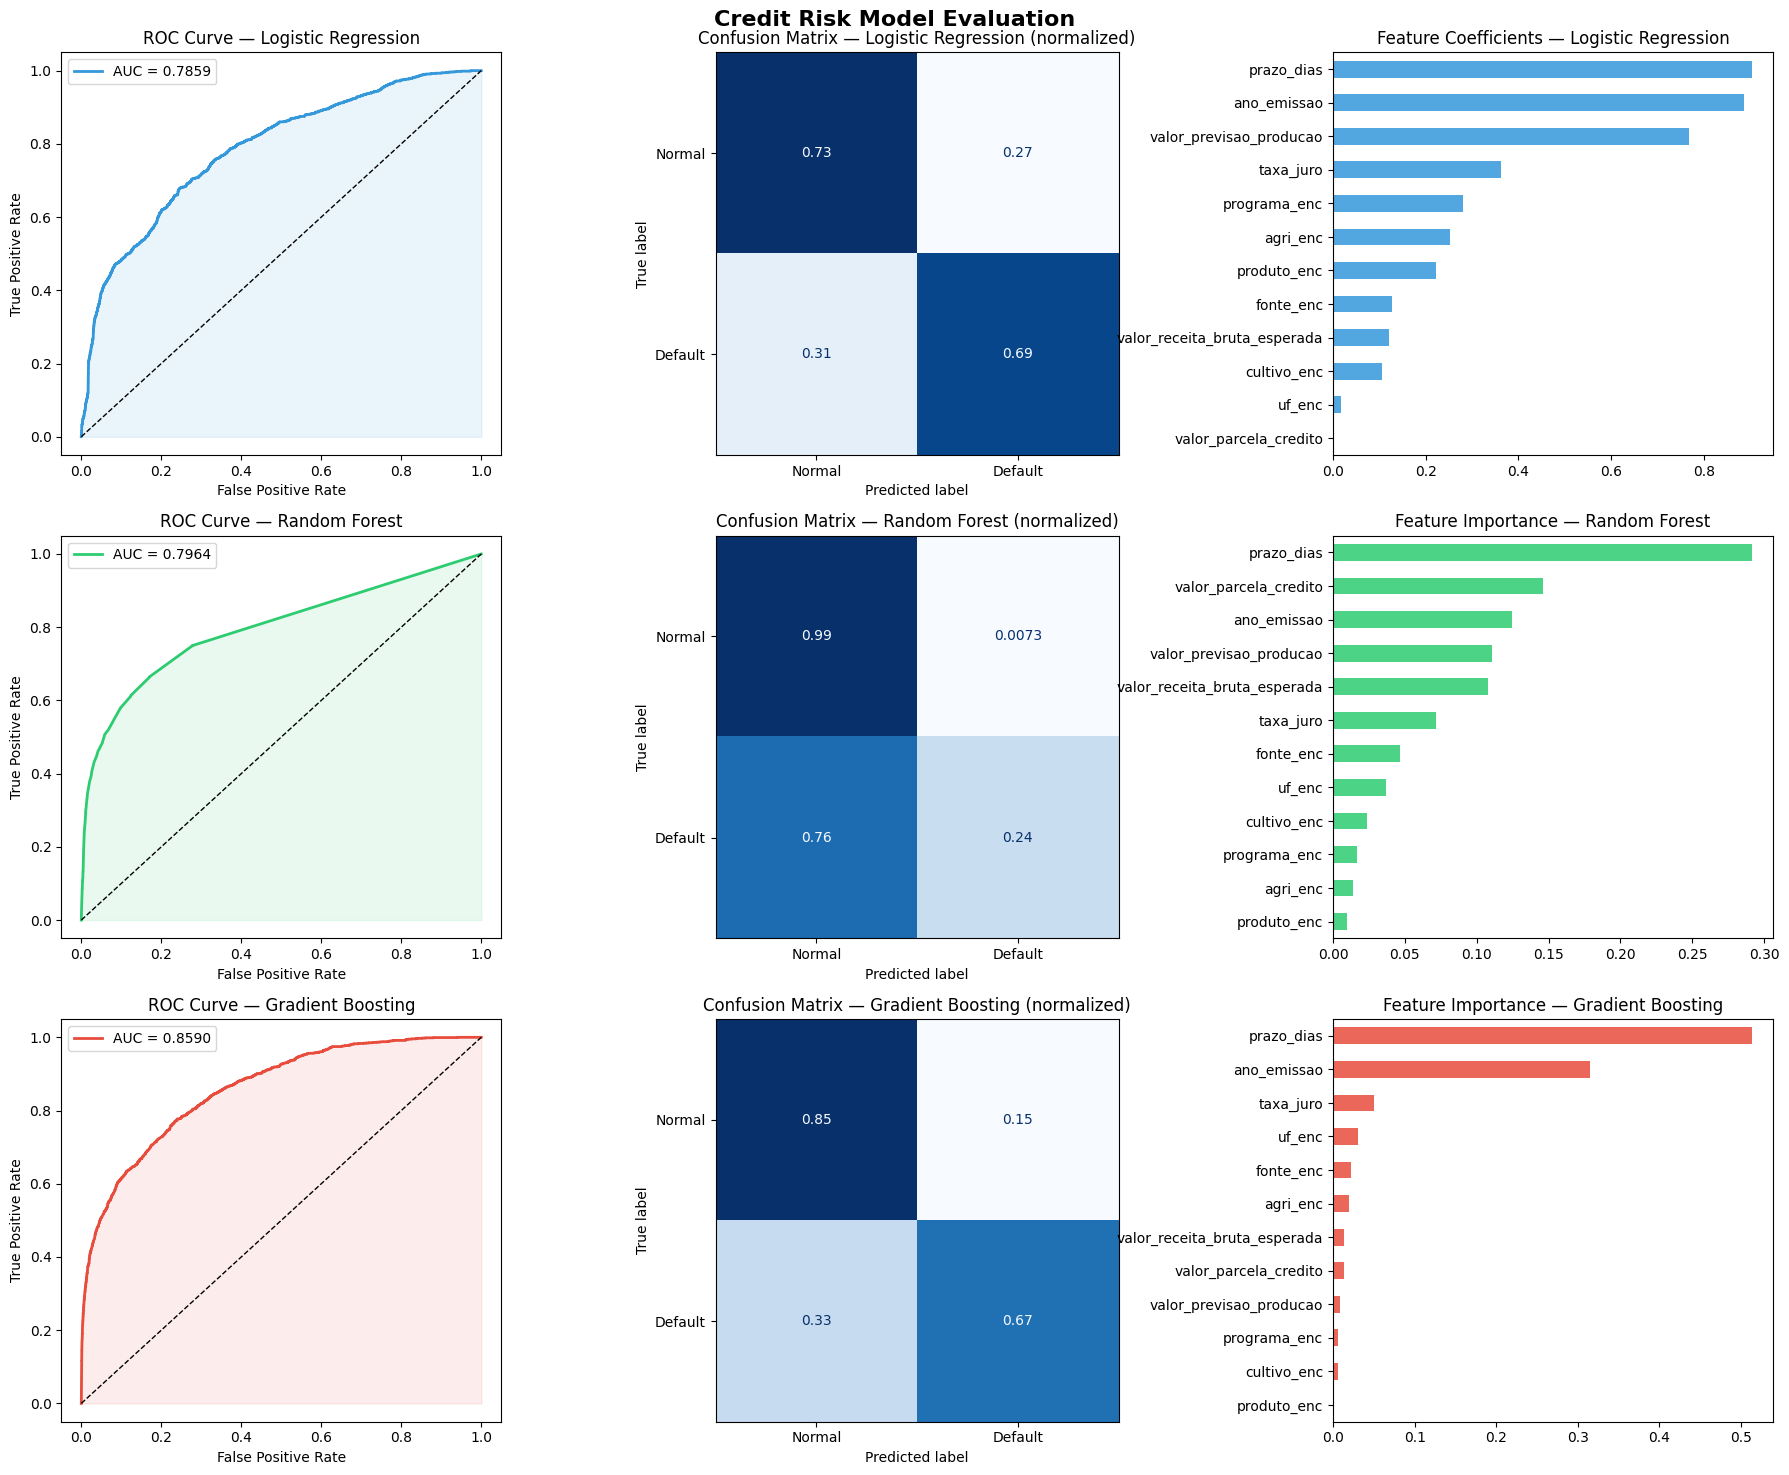

Saved!


In [8]:
# Cell 5 — Final visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Credit Risk Model Evaluation", fontsize=16, fontweight="bold")

colors = {"Logistic Regression": "#3498DB", 
          "Random Forest": "#2ECC71", 
          "Gradient Boosting": "#E74C3C"}

for i, (name, res) in enumerate(results.items()):
    color = colors[name]

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[i,0].plot(fpr, tpr, color=color, linewidth=2,
                   label=f"AUC = {res['auc']:.4f}")
    axes[i,0].plot([0,1],[0,1], "k--", linewidth=1)
    axes[i,0].fill_between(fpr, tpr, alpha=0.1, color=color)
    axes[i,0].set_title(f"ROC Curve — {name}")
    axes[i,0].set_xlabel("False Positive Rate")
    axes[i,0].set_ylabel("True Positive Rate")
    axes[i,0].legend(fontsize=10)

    # Confusion Matrix — normalized
    cm = confusion_matrix(y_test, res["y_pred"], normalize="true")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Normal", "Default"])
    disp.plot(ax=axes[i,1], colorbar=False, cmap="Blues")
    axes[i,1].set_title(f"Confusion Matrix — {name} (normalized)")

    # Feature Importance
    if hasattr(res["model"], "feature_importances_"):
        feat_imp = pd.Series(
            res["model"].feature_importances_,
            index=feature_cols
        ).sort_values(ascending=True)
        feat_imp.plot(kind="barh", ax=axes[i,2], color=color, alpha=0.85)
        axes[i,2].set_title(f"Feature Importance — {name}")
    else:
        coef = pd.Series(
            np.abs(res["model"].coef_[0]),
            index=feature_cols
        ).sort_values(ascending=True)
        coef.plot(kind="barh", ax=axes[i,2], color=color, alpha=0.85)
        axes[i,2].set_title(f"Feature Coefficients — {name}")

plt.tight_layout()
plt.savefig("../data/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

In [9]:
# Cell 6 — Save best model
import pickle
import os

os.makedirs("../src", exist_ok=True)

# Save best model (Gradient Boosting)
best_model = results["Gradient Boosting"]["model"]
best_model_data = {
    "model": best_model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "auc_roc": results["Gradient Boosting"]["auc"],
    "commodities": ["CAFÉ", "CANA-DE-AÇUCAR", "LARANJA"]
}

with open("../src/credit_risk_model.pkl", "wb") as f:
    pickle.dump(best_model_data, f)

print("Model saved!")
print(f"Best model: Gradient Boosting")
print(f"AUC-ROC: {results['Gradient Boosting']['auc']:.4f}")

# Final summary
print("\n=== FINAL MODEL COMPARISON ===")
summary = pd.DataFrame({
    "Model": list(results.keys()),
    "AUC-ROC": [res["auc"] for res in results.values()]
}).sort_values("AUC-ROC", ascending=False)
print(summary.to_string(index=False))

Model saved!
Best model: Gradient Boosting
AUC-ROC: 0.8590

=== FINAL MODEL COMPARISON ===
              Model  AUC-ROC
  Gradient Boosting 0.859003
      Random Forest 0.796448
Logistic Regression 0.785908
